<a href="https://colab.research.google.com/github/MJ-SU/AI_demo_in_colab/blob/main/%E6%89%93%E9%80%A0%E9%BB%9E%E5%BD%A9%E9%A2%A8%E6%A0%BC%E5%9C%96%E5%83%8F%E7%94%9F%E6%88%90%E5%99%A8WebUI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

透過gemini協助程式碼並依需求進行迭代
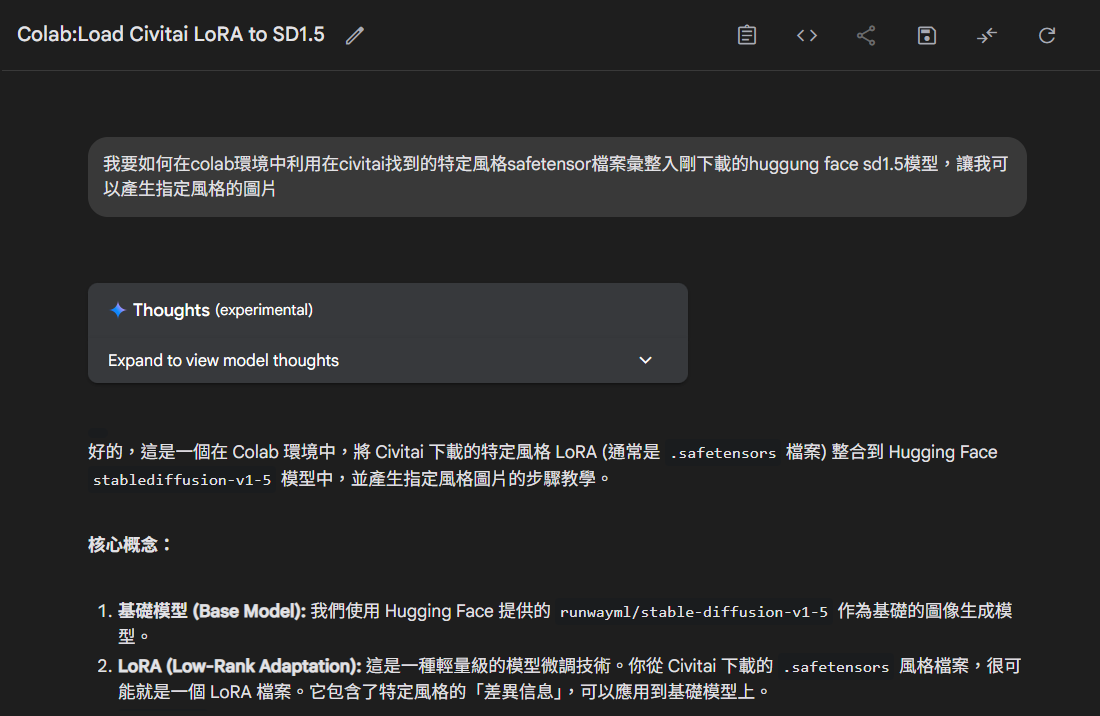

# 📚 打造 Stable Diffusion 的 WebUI

### 1. 安裝必要套件

In [ ]:
!pip install -q diffusers transformers accelerate safetensors huggingface_hub gradio --upgrade

In [ ]:
from diffusers import StableDiffusionPipeline, UniPCMultistepScheduler
import torch
import gc
import matplotlib.pyplot as plt
import gradio as gr
import random
from safetensors.torch import load_file
from PIL import Image
import os

In [ ]:
# from google.colab import userdata

# hf_token = userdata.get("HuggingFace")
# login(token=hf_token)

### 2. 基礎變數設定以及指定並讀入基本模型及Lora

In [ ]:
# 修正後的方法
lora_url = "https://civitai.com/api/download/models/1586529"
lora_filename = "Pointillism.safetensors"
lora_path = f"/content/{lora_filename}"  # 注意這裡使用絕對路徑 /content/

# 使用 curl 下載檔案
!curl -L -o {lora_path} "{lora_url}"

# 檢查檔案是否成功下載
!ls -la {lora_path}
print(f"LoRA 檔案已下載到: {lora_path}")

In [ ]:
# --- 全域變數設定 ---
# 基礎模型 ID
MODEL_ID = "runwayml/stable-diffusion-v1-5"
# LoRA 檔案名稱 (假設已上傳到 Colab 根目錄)
LORA_FILENAME = "Pointillism.safetensors"
LORA_ADAPTER_NAME = "pointillism_style" # 給 LoRA 一個自訂名稱

# 初始化 Hugging Face Pipeline (全域變數，只載入一次)
pipe = None
LORA_AUTHOR_TRIGGER_WORD = "Pointillism"

In [ ]:
# --- 預設提示詞 ---
DEFAULT_ENHANCE = "masterpiece, best quality, ultra high quality, intricate details, cinematic lighting"
DEFAULT_NEGATIVE = "blind, lowres, bad anatomy, extra limbs, disfigured, deformed, bad hands, bad feet, missing fingers, extra fingers, extra digit, fewer digits, poorly drawn hands, poorly drawn feet, poorly drawn face, out of frame, body out of frame, blurry, grainy, text, error, cropped, worst quality, low quality, normal quality, jpeg artifacts, signature, watermark, username, cut off, low contrast, underexposed, overexposed, bad art, beginner, amateur, distorted face, draft, ugly, tiling, ((black and white)), ((missing fingers)), ((extra fingers))"

In [ ]:
# 檢查 LoRA 檔案是否存在
if not os.path.exists(LORA_FILENAME):
    print(f"錯誤：LoRA 檔案 '{LORA_FILENAME}' 未在 Colab 根目錄中找到。請先上傳檔案。")
    # 你可以在這裡停止執行或拋出錯誤
    raise FileNotFoundError(f"LoRA 檔案 '{LORA_FILENAME}' 未找到。")
else:
    print(f"找到 LoRA 檔案: {LORA_FILENAME}")

In [ ]:
def load_model_and_lora():
    global pipe
    if pipe is not None:
        print("模型已載入。")
        return

    print("正在載入基礎模型 (stable-diffusion-v1-5)...")
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
    )
    pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
    pipe.to("cuda")
    print("基礎模型載入完成。")

    print(f"正在載入 LoRA 權重: {LORA_FILENAME}...")
    try:
        # 直接從根目錄載入 LoRA
        pipe.load_lora_weights(
            ".", # 代表當前目錄 (Colab 根目錄)
            weight_name=LORA_FILENAME,
            adapter_name=LORA_ADAPTER_NAME
        )
        print(f"LoRA '{LORA_FILENAME}' 已成功載入並命名為 '{LORA_ADAPTER_NAME}'。")
    except Exception as e:
        print(f"載入 LoRA 時發生錯誤: {e}")
        print("請確保 LoRA 檔案與 SD v1.5 模型兼容。")
        pipe = None # 如果 LoRA 載入失敗，重置 pipe
        raise

# 執行模型和 LoRA 載入
load_model_and_lora()

### 產生圖像函數設定

In [ ]:
#def generate_images_gradio(
    prompt_text,
    lora_trigger_word, # 新增 LoRA 觸發詞輸入
    lora_scale,        # 新增 LoRA 強度控制
    use_enhance_prompt,
    enhance_prompt_text,
    use_negative_prompt,
    negative_prompt_text,
    use_custom_seed,
    seed_value,
    img_height_str,
    img_width_str,
    num_steps,
    num_imgs,
    progress=gr.Progress(track_tqdm=True) # Gradio 進度條
):
    if pipe is None:
        # ******************** 修正點 ********************
        # 直接返回 None 給 Gallery，錯誤訊息給 Label
        return [None, "錯誤：模型未成功載入。請檢查前面的步驟並重新啟動執行階段 (如果需要)。"]
        # ***********************************************


    # --- 設定 LoRA ---
    # 每次生成前都設定一次，確保使用的是 UI 傳入的強度
    # 如果 lora_scale 為 0，則相當於停用 LoRA
    if lora_scale > 0:
        pipe.set_adapters([LORA_ADAPTER_NAME], adapter_weights=[lora_scale])
        print(f"已啟用 LoRA '{LORA_ADAPTER_NAME}'，強度: {lora_scale}")
        # 將觸發詞加入到 prompt 前面
        if lora_trigger_word and lora_trigger_word.strip():
             prompt_text = f"{lora_trigger_word.strip()}, {prompt_text}"
    else:
        pipe.set_adapters([], adapter_weights=[]) # 清空 adapters 以停用 LoRA
        print("LoRA 已停用 (強度設為 0)。")


    # --- 組合 Prompt ---
    if use_enhance_prompt and enhance_prompt_text:
        prompt_text = f"{prompt_text}, {enhance_prompt_text}"

    current_negative_prompt = ""
    if use_negative_prompt and negative_prompt_text:
        current_negative_prompt = negative_prompt_text

    # --- 轉換圖像尺寸 ---
    try:
        img_height = int(img_height_str)
        img_width = int(img_width_str)
    except ValueError:
        return [None, "錯誤：高度和寬度必須是有效的數字。"] # 同樣返回 None 給 Gallery


    images_list = []
    seeds_info_list = []

    print(f"\n--- 開始生成 ---")
    print(f"Prompt: {prompt_text}")
    print(f"Negative Prompt: {current_negative_prompt}")
    print(f"LoRA Trigger: {lora_trigger_word if lora_scale > 0 else 'N/A'}")
    print(f"LoRA Scale: {lora_scale if lora_scale > 0 else 'N/A'}")
    print(f"Steps: {num_steps}, Height: {img_height}, Width: {img_width}, Num Images: {num_imgs}")

    for i in range(num_imgs):
        current_seed = seed_value
        if not use_custom_seed or num_imgs > 1: # 如果生成多張圖，即使勾選自訂 seed，也只用它做第一張的 seed
            current_seed = random.randint(0, 2**32 - 1) if i > 0 or not use_custom_seed else seed_value

        seeds_info_list.append(f"Image {i+1} Seed: {current_seed}")
        print(f"Generating image {i+1}/{num_imgs} with seed: {current_seed}")

        generator = torch.Generator("cuda").manual_seed(current_seed)

        try:
            with torch.inference_mode(): # 確保在推斷模式下運行以節省記憶體
                generated_image = pipe(
                    prompt=prompt_text,
                    negative_prompt=current_negative_prompt,
                    height=img_height,
                    width=img_width,
                    num_inference_steps=int(num_steps),
                    guidance_scale=7.5, # 你也可以把這個做成 UI 選項
                    generator=generator,
                    # cross_attention_kwargs={"scale": lora_scale} # 使用 set_adapters 後，這個通常不需要
                ).images[0]
            images_list.append(generated_image)
        except Exception as e:
            print(f"生成圖像時發生錯誤: {e}")
            # 可以在這裡添加一個錯誤指示圖到 images_list，或者讓 Gallery 為空
            error_img = Image.new('RGB', (img_width, img_height), color = 'red') # 可選
            images_list.append(error_img) # 可選
            seeds_info_list[-1] += f" (生成失敗: {str(e)[:100]})" # 顯示部分錯誤訊息


    print("--- 生成完成 ---")
    return [images_list, "\n".join(seeds_info_list)]

In [ ]:
#迭代，處理AttributeError: type object 'Gallery' has no attribute 'update'
def generate_images_gradio(
    prompt_text,
    lora_trigger_word,
    lora_scale,
    use_enhance_prompt,
    enhance_prompt_text,
    use_negative_prompt,
    negative_prompt_text,
    use_custom_seed,
    seed_value,
    img_height_str,
    img_width_str,
    num_steps,
    guidance_value, # <--- guidance_value 在 num_imgs 之前
    num_imgs,
    progress=gr.Progress(track_tqdm=True)
):
    if pipe is None:
        return [None, "錯誤：模型未成功載入。請檢查前面的步驟並重新啟動執行階段 (如果需要)。"]

    # 1. 構造最終的 prompt
    final_prompt = prompt_text

    if lora_scale > 0:
        pipe.set_adapters([LORA_ADAPTER_NAME], adapter_weights=[lora_scale])
        print(f"已啟用 LoRA '{LORA_ADAPTER_NAME}'，強度: {lora_scale}")
        if lora_trigger_word and lora_trigger_word.strip():
             final_prompt = f"{lora_trigger_word.strip()}, {final_prompt}"
    else:
        pipe.set_adapters([], adapter_weights=[])
        print("LoRA 已停用 (強度設為 0)。")

    if use_enhance_prompt and enhance_prompt_text:
        final_prompt = f"{final_prompt}, {enhance_prompt_text}"

    # 2. 構造 negative prompt
    current_negative_prompt = ""
    if use_negative_prompt and negative_prompt_text:
        current_negative_prompt = negative_prompt_text

    # 3. 尺寸轉換
    try:
        img_height = int(img_height_str)
        img_width = int(img_width_str)
    except ValueError:
        return [None, "錯誤：高度和寬度必須是有效的數字。"]

    images_list = []
    seeds_info_list = []

    print(f"\n--- 開始生成 ---")
    print(f"最終 Prompt (送入模型): {final_prompt}")
    print(f"Negative Prompt: {current_negative_prompt}")
    print(f"LoRA Trigger (UI輸入): {lora_trigger_word if lora_scale > 0 else 'N/A'}")
    print(f"LoRA Scale: {lora_scale if lora_scale > 0 else 'N/A'}")
    print(f"Guidance Scale (CFG): {guidance_value}") # 打印正確的 guidance_value
    print(f"Steps: {num_steps}, Height: {img_height}, Width: {img_width}, Num Images: {num_imgs}")

    # ******************** 新的種子處理邏輯 ********************
    base_seed = seed_value # 將用戶指定的 seed 作為基礎種子

    for i in range(num_imgs):
        current_seed = 0 # 初始化 current_seed

        if use_custom_seed:
            # 如果勾選了自訂 seed，則第 i 張圖片的種子是 base_seed + i
            current_seed = int(base_seed) + i
        else:
            # 如果沒有勾選自訂 seed，則每張圖片都使用新的隨機種子
            current_seed = random.randint(0, 2**32 - 1)
        # *******************************************************

        seeds_info_list.append(f"Image {i+1} Seed: {current_seed}")
        print(f"Generating image {i+1}/{num_imgs} with seed: {current_seed}")

        generator = torch.Generator("cuda").manual_seed(current_seed)

        try:
            with torch.inference_mode():
                generated_image = pipe(
                    prompt=final_prompt,
                    negative_prompt=current_negative_prompt,
                    height=img_height,
                    width=img_width,
                    num_inference_steps=int(num_steps),
                    guidance_scale=float(guidance_value), # <--- 使用從 UI 傳入的 guidance_value
                    generator=generator,
                ).images[0]
            images_list.append(generated_image)
        except Exception as e:
            print(f"生成圖像時發生錯誤: {e}")
            seeds_info_list[-1] += f" (生成失敗: {str(e)[:100]})"

    print("--- 生成完成 ---")
    return [images_list, "\n".join(seeds_info_list)]

### 打造 Gradio Web App

In [ ]:
with gr.Blocks(theme=gr.themes.Default(), css=".gr-button {font-size: 18px; background: linear-gradient(to right, #667eea, #764ba2); color: white;}") as demo:
    gr.Markdown(f"""
    # 🎨 點彩風格圖像生成器
    歡迎使用！輸入提示詞、調整 LoRA 設定，立即生成你的點彩風格 (Pointillism) 作品！

    **重要提示:**
    1. 下方的 **LoRA 觸發詞** 已預設為 `{LORA_AUTHOR_TRIGGER_WORD}`
    2. **LoRA 強度 (Scale)** 通常在 0.6 到 1.0 之間效果較好。設為 0 則不使用 LoRA。
    3. 提示詞範例:The image shows a painting of a lake surrounded by trees at sunset with the sun setting in the background. The lake is still and peaceful reflecting the warm colors of the sky and the trees creating a tranquil atmosphere.,
      no humans, orange flower, tree, flower, solo, outdoors, colorful, yellow flower, pokemon (creature)
    """) # <--- Markdown 說明簡化

    with gr.Row():
        with gr.Column(scale=3):
            gr.Markdown("### 📝 核心提示詞與 LoRA 設定")
            prompt = gr.Textbox(label="主要提示詞 (Prompt)", placeholder="例如：a beautiful landscape, a portrait of a woman", lines=3)

            lora_trigger = gr.Textbox(
                label="LoRA 觸發詞 (Trigger Word)",
                value=LORA_AUTHOR_TRIGGER_WORD, # 設定預設觸發詞
                placeholder="例如：pointillism style, arttista", # 可以保留通用 placeholder
                lines=1
            )
            lora_scale_slider = gr.Slider(
                minimum=0.0,
                maximum=2.0,
                value=1.0, # <--- 恢復為通用的預設強度，例如 0.75
                step=0.05,
                label="LoRA 強度 (Scale)"
            )

            gr.Markdown("### ✨ 效果加強 (可選)")
            with gr.Row():
                use_enhance = gr.Checkbox(label="加強 Prompt", value=True)
                enhance_text = gr.Textbox(label="加強內容", value=DEFAULT_ENHANCE, lines=2)

            gr.Markdown("### 🚫 排除內容 (可選)")
            with gr.Row():
                use_negative = gr.Checkbox(label="使用 Negative Prompt", value=True)
                negative_text = gr.Textbox(label="Negative Prompt 內容", value=DEFAULT_NEGATIVE, lines=2)

            gr.Markdown("### ⚙️ 生成參數")
            with gr.Row():
                height_dd = gr.Dropdown(["512", "768", "640", "576"], label="高度 Height", value="512") # SD1.5 常用尺寸
                width_dd = gr.Dropdown(["512", "768", "640", "576"], label="寬度 Width", value="512")

            with gr.Row():
                steps_slider = gr.Slider(10, 100, value=30, step=1, label="生成步數 (Steps)") # 增加步數上限
                guidance_slider = gr.Slider(
                    minimum=1.0,
                    maximum=20.0, # 通常 CFG 不會設超過 20-30
                    value=7.5,    # 預設值
                    step=0.5,
                    label="引導強度 (Guidance Scale / CFG)"
                )
                num_images_slider = gr.Slider(1, 8, step=1, value=1, label="生成張數") # 增加生成張數上限

            with gr.Row():
                use_custom_seed_cb = gr.Checkbox(label="自訂 Random Seed", value=False)
                custom_seed_num = gr.Number(label="指定 Seed (若不勾選則隨機)", value=42, precision=0)

            generate_btn = gr.Button("🚀 開始生成！")

        with gr.Column(scale=2): # 右側結果展示
            gr.Markdown("### 🖼️ 生成結果")
            gallery_output = gr.Gallery(label="Generated Images", columns=2, object_fit="contain", height="auto", preview=True)
            seed_info_output = gr.Label(label="使用的 Random Seeds")

    # 將 Gradio 組件連接到生成函數
    inputs_list = [
      prompt,
      lora_trigger,
      lora_scale_slider,
      use_enhance,
      enhance_text,
      use_negative,
      negative_text,
      use_custom_seed_cb,
      custom_seed_num,      # 對應 seed_value
      height_dd,
      width_dd,
      steps_slider,
      guidance_slider,      # 對應 guidance_value
      num_images_slider     # 對應 num_imgs
    ]
    outputs_list = [gallery_output, seed_info_output]

    generate_btn.click(
        fn=generate_images_gradio,
        inputs=inputs_list,
        outputs=outputs_list
    )

    gr.Markdown("""
    ---
    ### 💡 使用技巧:
    - **LoRA 強度 (Scale):** 一般 `0.7` 到 `0.85` 是個不錯的開始。過高可能會導致風格過於強烈或圖像失真。
    - **Prompt Engineering:** 嘗試不同的主體、場景描述，並結合加強和排除內容來達到最佳效果。
    - **Seed:** 使用固定的 Seed 可以讓你重現相同的圖片。取消勾選 "自訂 Random Seed" 則每次生成都會是新的隨機結果。
    - **引導強度 (Guidance Scale / CFG):** 控制圖像與提示詞的符合程度。較低的值（如 3-6）會產生更具創意性但可能偏離提示的圖像；較高的值（如 7-15）會使圖像更貼近提示，但可能缺乏多樣性。建議從 7.5 開始調整。
    - **尺寸與步數:** 較大的尺寸和較多的步數會需要更長的生成時間和更多的 GPU 記憶體。
    """)

# 啟動 Gradio 應用
demo.launch(share=True, debug=True)